In [1]:
import numpy as np
import pickle
import torch
from scipy.stats import binom, norm
from math import sqrt, pi, exp
from matplotlib import pyplot as plt
from tools import load, estimate_derivative, whiten

device = torch.device('mps' if torch.backends.mps.is_available() else
                       'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


In [2]:
def _phi(x):
    return (1.0 / sqrt(2.0 * pi)) * exp(-0.5 * x * x)


def K(r, s, n_terms=30):
    """Kernel for top-k via Mehler's Hermite series."""
    if not (0.0 < s < 1.0):
        raise ValueError('s must be in (0,1).')
    r = float(r)
    r = min(r, np.nextafter(1.0, 0.0))
    r = max(r, np.nextafter(-1.0, 0.0))
    d = 1.0 - s
    t = float(norm.ppf(s))
    phi_t = _phi(t)
    a_prev = d
    a_curr = phi_t
    rn_nfact = 1.0
    result = rn_nfact * a_prev * a_prev
    for n in range(1, n_terms + 1):
        rn_nfact *= r / n
        result += rn_nfact * a_curr * a_curr
        a_next = t * a_curr - (n - 1) * a_prev
        a_prev = a_curr
        a_curr = a_next
    return result / d

In [3]:
# Shared gridsearch parameters (same as gs_single_2 / gs_binary_2)
n_hd = 10000
n_pairs = 10000
s_sweep = np.concatenate([np.arange(0.01, 0.05, 0.02), np.arange(0.1, 0.5, 0.1)])
p_hd_sweep = np.arange(0.05, 0.50, 0.1)
rs_theory = np.arange(0, 1.01, 0.01)

print(f's_sweep:     {s_sweep}')
print(f'p_hd_sweep:  {p_hd_sweep}')

s_sweep:     [0.01 0.03 0.1  0.2  0.3  0.4 ]
p_hd_sweep:  [0.05 0.15 0.25 0.35 0.45]


In [4]:
def compute_scatter_data(x_dense_t, s_sweep, p_hd_sweep, n_hd, n_pairs, device):
    """Compute dense cosine similarity and sparse kernel overlap for all (s, p_hd) combos."""
    n_samples = x_dense_t.shape[0]
    n_dense = x_dense_t.shape[1]

    # Pre-sample pairs
    pair_indices = np.array([np.random.choice(n_samples, size=2, replace=False)
                             for _ in range(n_pairs)])
    idx1 = torch.tensor(pair_indices[:, 0], device=device)
    idx2 = torch.tensor(pair_indices[:, 1], device=device)

    # Dense cosine similarity
    v1 = x_dense_t[idx1]
    v2 = x_dense_t[idx2]
    cos_dense = (v1 * v2).sum(dim=1) / (v1.norm(dim=1) * v2.norm(dim=1))
    cos_dense_np = cos_dense.cpu().numpy()

    x_array = np.zeros((len(s_sweep), len(p_hd_sweep), n_pairs))
    y_array = np.zeros((len(s_sweep), len(p_hd_sweep), n_pairs))

    for l, p_hd in enumerate(p_hd_sweep):
        W_hd = torch.bernoulli(torch.full((n_hd, n_dense), p_hd, device=device))
        x_hd = x_dense_t @ W_hd.T

        for j, s in enumerate(s_sweep):
            k = int(s * n_hd)
            _, topk_idx = torch.topk(x_hd, k, dim=1, largest=True)
            z_hd = torch.zeros_like(x_hd)
            z_hd.scatter_(1, topk_idx, 1.0)

            cos_hd = (z_hd[idx1] * z_hd[idx2]).sum(dim=1) / k

            x_array[j, l] = cos_dense_np
            y_array[j, l] = cos_hd.cpu().numpy()

    return x_array, y_array

In [5]:
def build_acc_lookup(gs_data):
    """Build dict mapping (normalized, s, p_hd) -> mean test accuracy over folds."""
    s_arr   = np.asarray(gs_data['params']['s'])
    phd_arr = np.asarray(gs_data['params']['p_hd'])
    nm_arr  = np.asarray(gs_data['params']['normalized'])
    acc     = np.asarray(gs_data['results']['test_acc'], dtype=float)

    lookup = {}
    for nv in np.unique(nm_arr):
        for s in np.unique(s_arr):
            for ph in np.unique(phd_arr):
                mask = (nm_arr == nv) & (np.isclose(s_arr, s)) & (np.isclose(phd_arr, ph))
                if mask.any():
                    lookup[(nv, round(s, 4), round(ph, 4))] = np.mean(acc[mask])
    return lookup

In [6]:
def plot_kernel_scatter(x_array, y_array, s_sweep, p_hd_sweep, n_dense,
                        acc_lookup, norm_label, title_prefix):
    """Plot histogram row + scatter grid with accuracy overlay."""
    n_rows = len(s_sweep) + 1
    n_cols = len(p_hd_sweep)
    x_binom = np.arange(0, n_dense + 1)

    fig, ax = plt.subplots(
        n_rows, n_cols,
        figsize=(2.2 * n_cols, 2.2 * n_rows),
        gridspec_kw={'wspace': 0.4, 'hspace': 0.4,
                     'height_ratios': [1.2] + [1] * len(s_sweep)}
    )
    fig.suptitle(f'{title_prefix} — {norm_label}', fontsize=13, fontweight='bold')

    # Row 0: Binomial(n_dense, p_hd) histograms
    for j, p_hd in enumerate(p_hd_sweep):
        pmf = binom.pmf(x_binom, n_dense, p_hd)
        ax[0, j].bar(x_binom, pmf, color='C2', width=0.8)
        ax[0, j].set_title(f'$p_{{hd}}={p_hd:.2f}$', fontsize=9)
        ax[0, j].set_xlabel('$x$')
        ax[0, j].set_xticks(np.arange(2) * n_dense)
        if j == 0:
            ax[0, j].set_ylabel(r'$P(X{=}x)$')
        else:
            ax[0, j].set_yticklabels([])

    # Scatter plots
    for i, s in enumerate(s_sweep):
        row = i + 1
        s_theory = 1 - s
        vals_theory = [K(r=ri, s=s_theory) for ri in rs_theory]

        for j, p_hd in enumerate(p_hd_sweep):
            x = x_array[i, j]
            y = y_array[i, j]

            ax[row, j].plot(x, y, '.', alpha=0.5, ms=1, clip_on=False, color='C0')
            ax[row, j].plot(rs_theory, vals_theory, '--', color='black',
                            linewidth=1., clip_on=False)

            # Accuracy overlay
            key = (norm_label, round(s, 4), round(float(p_hd), 4))
            if key in acc_lookup:
                acc_val = acc_lookup[key]
                ax[row, j].text(0.05, 0.95, f'acc={acc_val:.2f}',
                                transform=ax[row, j].transAxes,
                                ha='left', va='top', fontsize=7,
                                bbox=dict(boxstyle='round,pad=0.2',
                                          fc='white', ec='gray', alpha=0.8))

            ax[row, j].set_xticks([0, 0.5, 1])
            ax[row, j].set_yticks([0, 0.5, 1])

            if j == 0:
                ax[row, j].set_ylabel(r'$K({x}_{1}, {x}_{2})$')
                ax[row, j].text(-0.55, 0.5, f'$s={s:.2f}$',
                                transform=ax[row, j].transAxes,
                                ha='center', va='center', fontsize=9, clip_on=False)
            else:
                ax[row, j].set_yticks([0, 0.5, 1], labels=[])
                ax[row, j].set_ylabel('')

            if row == n_rows - 1:
                ax[row, j].set_xlabel(r'$\langle {x}_{1}, {x}_{2} \rangle$')
            else:
                ax[row, j].set_xticks([0, 0.5, 1], labels=[])
                ax[row, j].set_xlabel('')

    plt.tight_layout()
    plt.show()

## Single odour (`gs_single_2`)

Data: `1_600_20` — 8 sensors + derivatives = 16 features.  
Top-k kernel scatter plots for each (s, p_hd), with mean test accuracy overlaid.

In [7]:
# Load single-odour data (same as gridsearch_single.py)
sensor_data_s, sequence_s, times_sec_s, sequence_sec_s = load('1_600_20', reduced=True)
d_sensor_s = np.apply_along_axis(estimate_derivative, axis=0, arr=sensor_data_s)
sensor_data_s = np.hstack((sensor_data_s, d_sensor_s))

n_train_s = 450
labels_s = np.zeros_like(times_sec_s)
for i, t in enumerate(sequence_sec_s[:n_train_s]):
    try:
        flag = (times_sec_s > sequence_sec_s[i]) & (times_sec_s < sequence_sec_s[i+1])
    except IndexError:
        flag = (times_sec_s > sequence_sec_s[i])
    labels_s[flag] = int(sequence_s[i][1])
idx_first_s = np.where(labels_s != 0)[0][0]

# Load accuracy results
with open('data/gs_single_2.pkl', 'rb') as f:
    gs_single_2 = pickle.load(f)
acc_lookup_s = build_acc_lookup(gs_single_2)

print(f'Single sensor_data shape: {sensor_data_s.shape}')
print(f'Dense features from idx {idx_first_s}: {sensor_data_s[idx_first_s:].shape}')

Single sensor_data shape: (11691, 16)
Dense features from idx 299: (11392, 16)


/var/folders/w2/znr__42x45s1rjb1hj583bbr0000gn/T/ipykernel_11907/2662240052.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


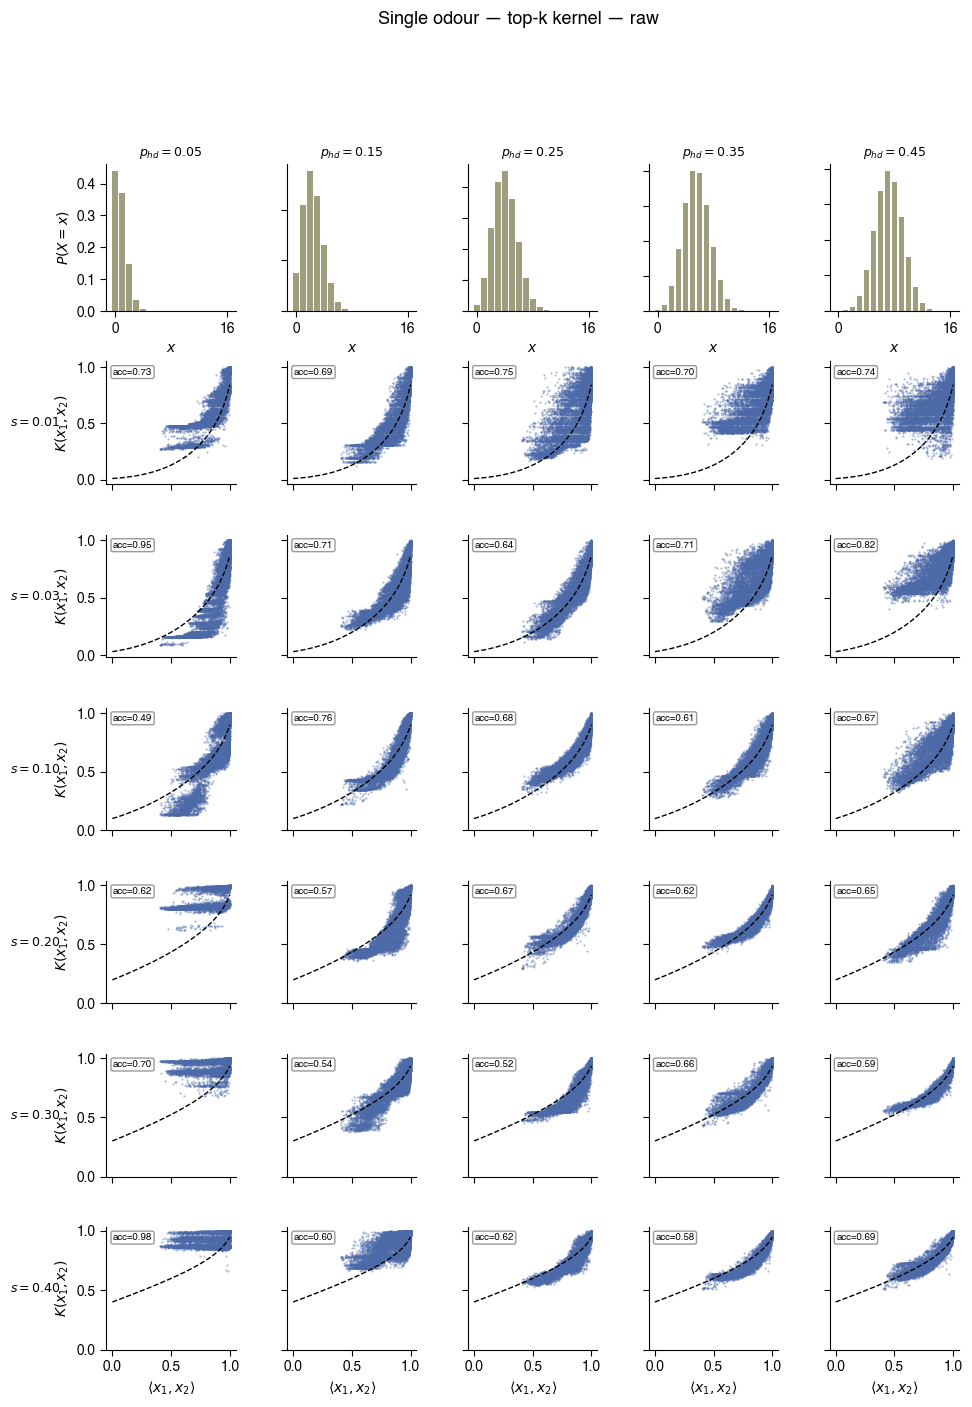

In [8]:
# Raw
x_dense_raw_s = torch.tensor(sensor_data_s[idx_first_s:], dtype=torch.float32, device=device)
x_arr_raw_s, y_arr_raw_s = compute_scatter_data(x_dense_raw_s, s_sweep, p_hd_sweep,
                                                 n_hd, n_pairs, device)
plot_kernel_scatter(x_arr_raw_s, y_arr_raw_s, s_sweep, p_hd_sweep,
                    sensor_data_s.shape[1], acc_lookup_s, 'raw',
                    'Single odour — top-k kernel')

/var/folders/w2/znr__42x45s1rjb1hj583bbr0000gn/T/ipykernel_11907/2662240052.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


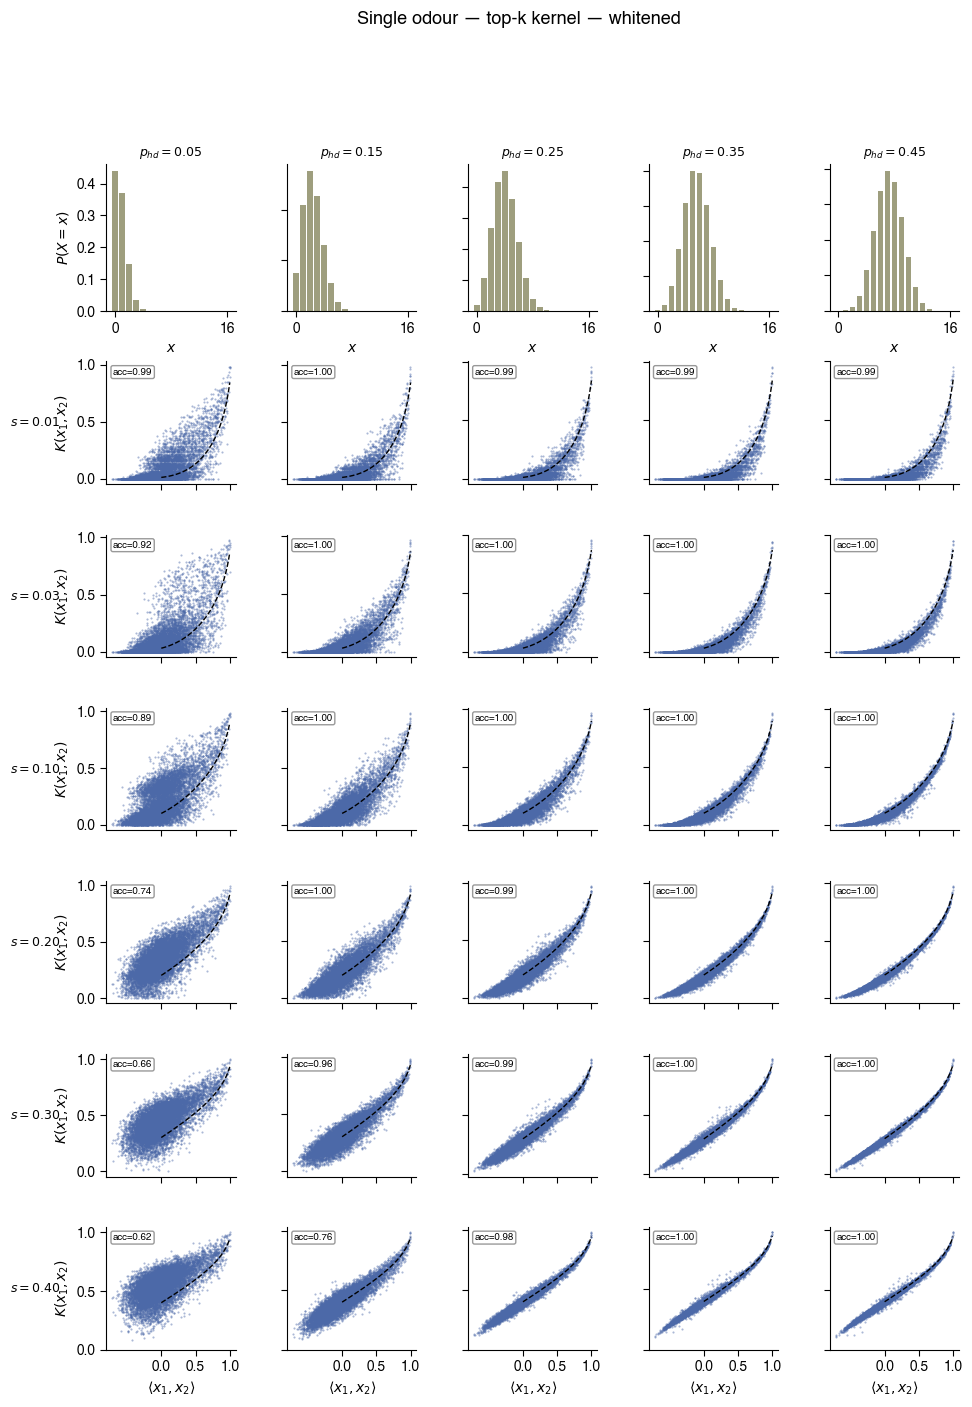

In [9]:
# Whitened
x_dense_wh_s = torch.tensor(whiten(sensor_data_s)[idx_first_s:], dtype=torch.float32, device=device)
x_arr_wh_s, y_arr_wh_s = compute_scatter_data(x_dense_wh_s, s_sweep, p_hd_sweep,
                                                n_hd, n_pairs, device)
plot_kernel_scatter(x_arr_wh_s, y_arr_wh_s, s_sweep, p_hd_sweep,
                    sensor_data_s.shape[1], acc_lookup_s, 'whitened',
                    'Single odour — top-k kernel')

## Binary mixtures (`gs_binary_2`)

Data: `mix_100_20_1` (train) + `mix_50_20_1` (test) — 8 sensors + derivatives = 16 features.  
Scatter plots computed on the training data.

In [10]:
# Load binary-mixture data (same as gridsearch_binary.py)
train_data_b, train_seq_b, train_ts_b, train_ss_b = load('mix_100_20_1', reduced=True)
train_d_b = np.apply_along_axis(estimate_derivative, axis=0, arr=train_data_b)
train_data_b = np.hstack((train_data_b, train_d_b))

# Load accuracy results
with open('data/gs_binary_2.pkl', 'rb') as f:
    gs_binary_2 = pickle.load(f)
acc_lookup_b = build_acc_lookup(gs_binary_2)

print(f'Binary train_data shape: {train_data_b.shape}')

Binary train_data shape: (11445, 16)


/var/folders/w2/znr__42x45s1rjb1hj583bbr0000gn/T/ipykernel_11907/2662240052.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


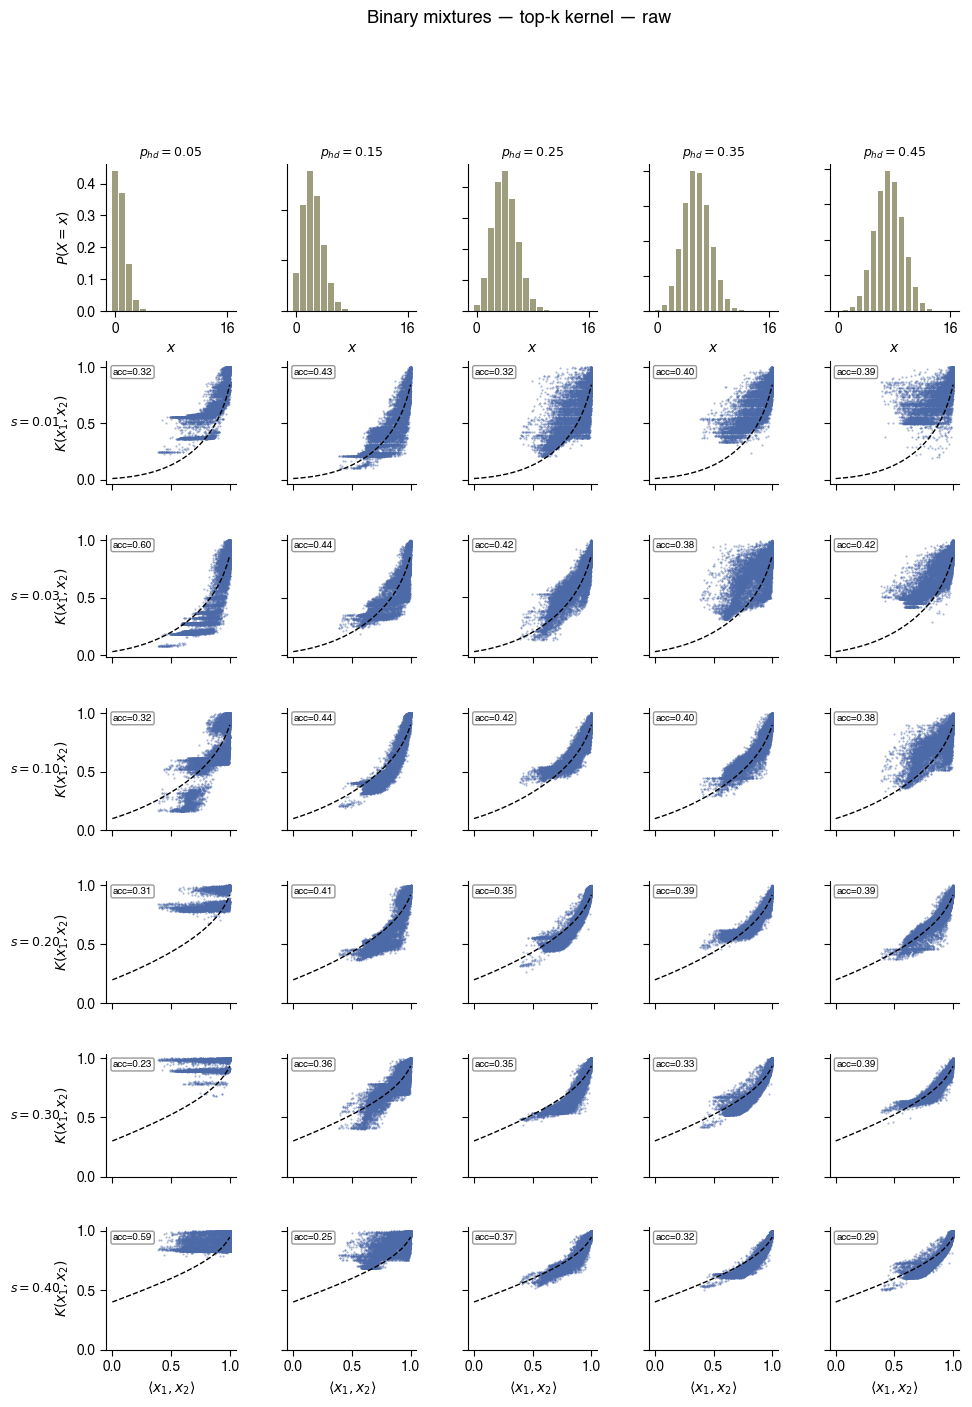

In [11]:
# Raw
x_dense_raw_b = torch.tensor(train_data_b, dtype=torch.float32, device=device)
x_arr_raw_b, y_arr_raw_b = compute_scatter_data(x_dense_raw_b, s_sweep, p_hd_sweep,
                                                  n_hd, n_pairs, device)
plot_kernel_scatter(x_arr_raw_b, y_arr_raw_b, s_sweep, p_hd_sweep,
                    train_data_b.shape[1], acc_lookup_b, 'raw',
                    'Binary mixtures — top-k kernel')

/var/folders/w2/znr__42x45s1rjb1hj583bbr0000gn/T/ipykernel_11907/2662240052.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


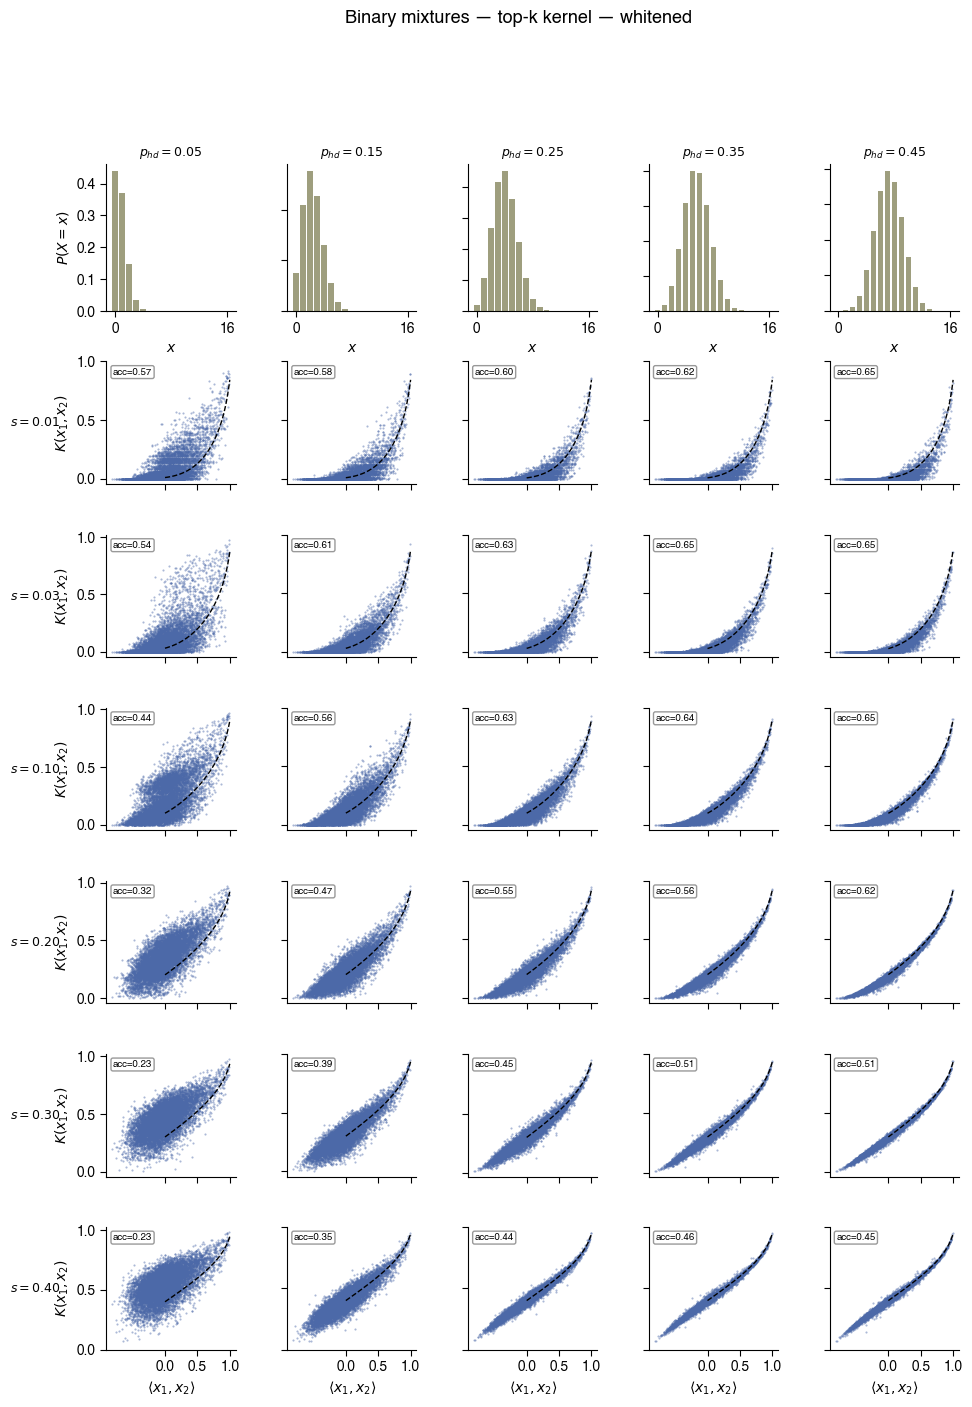

In [12]:
# Whitened
x_dense_wh_b = torch.tensor(whiten(train_data_b), dtype=torch.float32, device=device)
x_arr_wh_b, y_arr_wh_b = compute_scatter_data(x_dense_wh_b, s_sweep, p_hd_sweep,
                                                n_hd, n_pairs, device)
plot_kernel_scatter(x_arr_wh_b, y_arr_wh_b, s_sweep, p_hd_sweep,
                    train_data_b.shape[1], acc_lookup_b, 'whitened',
                    'Binary mixtures — top-k kernel')